In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.
from jaxopt import Bisection, Broyden, ScipyBoundedMinimize
import blackjax

import gpjax as gpx
from tensorflow_probability.substrates import jax as tfp
from tensorflow_probability.substrates.jax.mcmc import sample_halton_sequence

from numba import njit
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import sys
sys.path.append("..")
from src import GP, GPBanditSampler, HaltonSequence, MMD

/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


In [2]:
#===========================================
# Class and Function
#===========================================

#for reproducibility
class Random_Generator():
    def __init__(self, seed_id=0):
        self.seed_id = seed_id - 1 #-1 at init because seed_id will be count up before the noise generation.
        
    def generate_noise(self, size=0):
        self.seed_id = self.seed_id + 1
        return np.random.default_rng(seed=self.seed_id).normal(size=size)
    
@njit
def generate_force(input_t, noise_t, phi=0.4):
    force_t = np.zeros((input_t.shape[0], 40))
    force_t[0] = np.sqrt(1.0 - phi**2) * noise_t[0]
    for i in range(1, input_t.shape[0]):
        force_t[i] = phi * force_t[i-1] + np.sqrt(1.0 - phi**2) * noise_t[i]
    return force_t

@njit
def derivative(t, X, theta, force):
    dX_dt = np.zeros(40)
    for i in range(40):
        idx = int(t / delta_t)
        dX_dt[i] = - X[(i-1)%40] * ( X[(i-2)%40] - X[(i+1)%40] ) - X[i] + 10 - theta[0] - theta[1] * X[i] + force[idx, i]
    return dX_dt

@njit
def summary_stats(values_t):
    stats = np.zeros(6)
    for k in range(40):
        xk = values_t[k]
        xk_next = values_t[(k+1)%40]
        xk_back = values_t[(k-1)%40]
        stats[0] += np.mean(xk)
        stats[1] += np.var(xk)
        stats[2] += ( xk[1:] - np.mean(xk) ) @ ( xk[:-1] - np.mean(xk) ) / (161-1)
        stats[3] += ( xk - np.mean(xk) ) @ ( xk_next - np.mean(xk_next) ) / 161
        stats[4] += ( xk[1:] - np.mean(xk) ) @ ( xk_back[:-1] - np.mean(xk_back) ) / (161-1)
        stats[5] += ( xk[1:] - np.mean(xk) ) @ ( xk_next[:-1] - np.mean(xk_next) ) / (161-1)
    return stats / 40


In [3]:
#===========================================
# Hyperparameter
#===========================================

randomg = Random_Generator(seed_id=0)
delta_t = 0.025
index_t = np.arange(0, 161)
input_t = index_t * delta_t
state_0 = randomg.generate_noise(size=40)
theta_0 = np.array([2.0, 0.1])
sim_num = 1000


<BarContainer object of 6 artists>

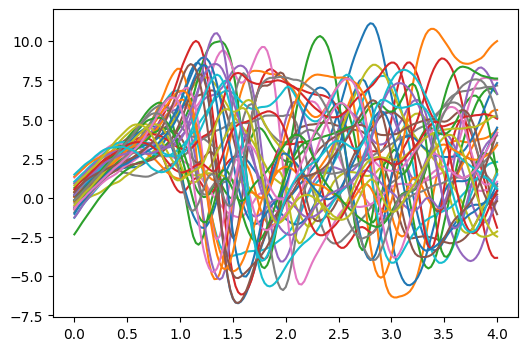

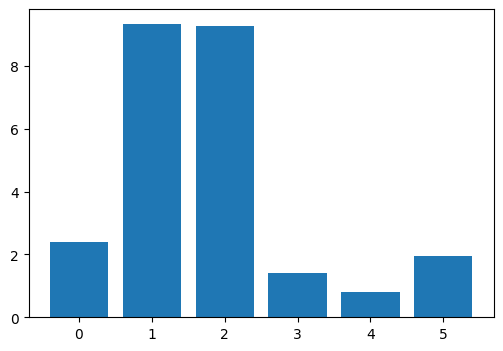

In [4]:
#===========================================
# Generate Data
#===========================================

noise_t = randomg.generate_noise(size=(index_t.shape[0],40))
force_t = generate_force(input_t, noise_t)
solve_t = sp.integrate.solve_ivp(fun=derivative, t_span=(0.0, 4.0), y0=state_0, t_eval=input_t, args=(theta_0, force_t)).y
stats_0 = summary_stats(solve_t)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for i in range(40):
    sns.lineplot(x=input_t, y=solve_t[i], ax=ax)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.bar(np.arange(6), height=stats_0)


In [5]:
#===========================================
# Posterior
#===========================================

def simulate_stats_each(theta):
    noise_t = randomg.generate_noise(size=(index_t.shape[0], 40))
    force_t = generate_force(input_t, noise_t)
    sdata_t = sp.integrate.solve_ivp(fun=derivative, t_span=(0.0, 4.0), y0=state_0, t_eval=input_t, args=(theta, force_t)).y
    return summary_stats(sdata_t)

def synthetic_loglikelihood(theta):
    stats_N = np.vstack([ simulate_stats_each(theta) for n in range(sim_num) ])
    stats_N_m = np.mean(stats_N, axis=0)
    stats_N_v = np.cov(stats_N.T)
    return sp.stats.multivariate_normal.logpdf(stats_0, mean=stats_N_m, cov=stats_N_v)

def logprior(theta):
    return - np.log( 3.0 * 0.3 )

def logposterior(theta):
    return synthetic_loglikelihood(theta) + logprior(theta)


In [6]:
#===========================================
# Excute
#===========================================

key = jrandom.key(0)
key, _key = jax.random.split(key)
bounds = ( jnp.array([0.0, 0.0]), jnp.array([5.0, 0.5]) )
halton = HaltonSequence(dim=2, bounds=bounds, rngkey=_key)
bandit = GPBanditSampler(n_init=10, n_eval=2048, sequence=halton)

X = halton.generate(jnp.arange(10))
y = jnp.array([ logposterior(x) for x in X ])
w = jnp.exp( y - jsp.special.logsumexp( y ) )

for ith in range(10, 100):
    #====== fit GP ======
    gp_mean = lambda x: 0.0
    gp_kernel = gpx.kernels.RBF(n_dims=2, lengthscale=jnp.array([1.0, 1.0]), variance=jnp.array([5.0]))
    gp = GP(gp_mean, gp_kernel)
    key, _key = jax.random.split(key)
    gp.tune_kernel_parameter(X, y, rng_key=_key)
    gp.fit(X, y)
    posterior_mean = jax.vmap(gp.posterior_mean, in_axes=0, out_axes=0)
    posterior_scale = jax.vmap(gp.posterior_scale, in_axes=0, out_axes=0)
    objective = jax.vmap(gp.jensen_exp, in_axes=0, out_axes=0)
    #====================
    
    #====== fit KH ======
    X_new = bandit.find(objective)
    y_new = logposterior(X_new)
    #====================
    
    #=== Stack point ====
    X = jnp.vstack((X, X_new))
    y = jnp.hstack((y, y_new))
    w = jnp.exp( y - jsp.special.logsumexp( y ) )
    #====================


  0%|          | 0/1000 [00:00<?, ?it/s]

/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

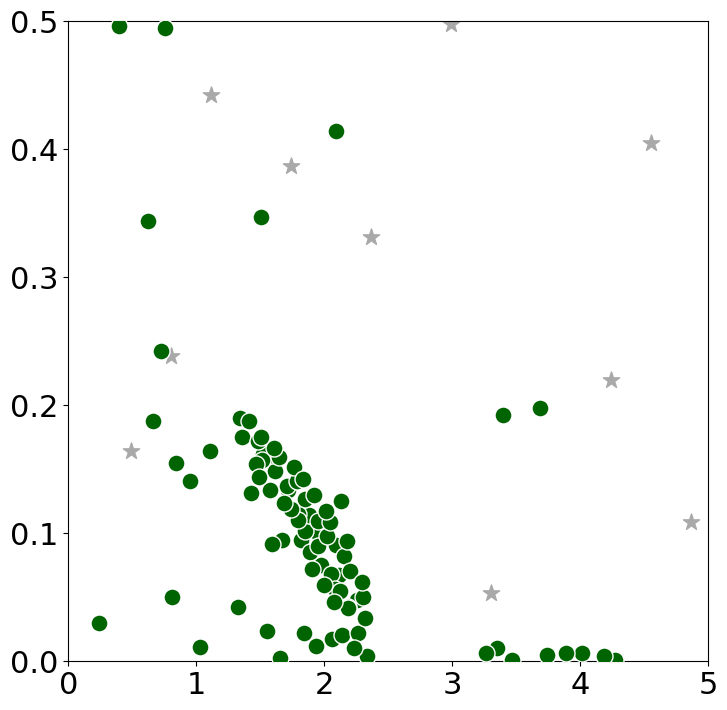

In [7]:
#===========================================
# Visualise Samples
#===========================================

def plot_sample(X, init_num=10, bounds=((-10,-10), (10,10))):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    n_grids = 500
    plt_x = jnp.linspace(bounds[0][0], bounds[1][0], n_grids)
    plt_y = jnp.linspace(bounds[0][1], bounds[1][1], n_grids)
    plt_x_, plt_y_ = jnp.meshgrid(plt_x, plt_y)

    ax.scatter(X[:init_num,0], X[:init_num,1], label="Initial Evaluation", s=150, marker="*", color='darkgray', zorder=2)
    ax.scatter(X[init_num:,0], X[init_num:,1], label="Samples", s=150, marker="o", color='darkgreen', edgecolor="white", zorder=3)   
    ax.set_xlim(bounds[0][0], bounds[1][0])
    ax.set_ylim(bounds[0][1], bounds[1][1])
    ax.tick_params(axis='both', which='major', labelsize=22)
    
    fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

plot_sample(X, init_num=10, bounds=bounds)


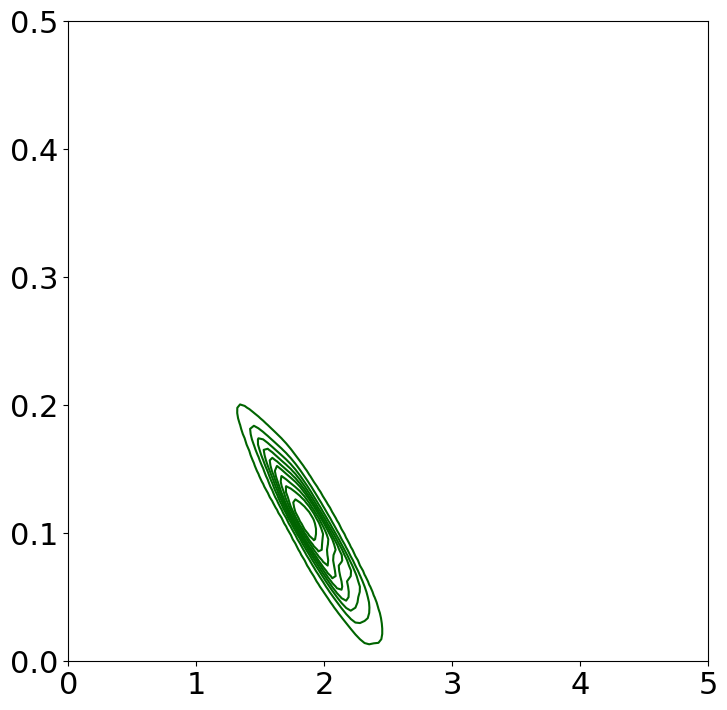

In [38]:
#===========================================
# Visualise KDE
#===========================================

def plot_density(X, w, init_num=10, bounds=((-10,-10), (10,10))):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    sns.kdeplot(x=X[:,0], y=X[:,1], weights=w, ax=ax, color="darkgreen", levels=10)
    ax.set_xlim(bounds[0][0], bounds[1][0])
    ax.set_ylim(bounds[0][1], bounds[1][1])
    ax.tick_params(axis='both', which='major', labelsize=22)
    
    fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

plot_density(X, w, init_num=10, bounds=bounds)


In [9]:
#===========================================
# Compute Error
#===========================================

target_samples = jnp.load('Data/samples_10000.npy')
target_weights = jnp.load('Data/weights_10000.npy')
sample_error = MMD(gpx.kernels.RBF(n_dims=2, lengthscale=0.1, variance=1.0), target_samples, target_weights)
print("Loss: {:f}".format(sample_error.compute(X, w)))


Loss: 0.008002
